In [1]:
import os
import sys
# set gpu to be pci bus id
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
# set gpu memory usage and turnoff pre-allocated memory TODO: what does the following do??
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] ='false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR']='platform'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [2]:
import jax
from jax import random
from jax import lax

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import equinox as eqx
from typing import Tuple, Optional

In [3]:
sys.path.append('/home/jmathew_waller/workspace/e2e-imaging/')
from psf_modules import RMLPSFLayer
from lensless_data_generator import LenslessDataGenerator
from optimizers import E2EOptimizer

2026-03-02 08:46:42.168391: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772470002.186166 1856719 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772470002.191968 1856719 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
def conv2d(x: jnp.ndarray, psf: jnp.ndarray) -> jnp.ndarray:
    psf = psf[::-1, ::-1]
    K, L = psf.shape

    # Pad fully so conv_valid gives the 'full' result
    x_padded = jnp.pad(x, ((0,0), (K-1, K-1), (L-1, L-1)))
    x4 = x_padded[:, :, :, None]
    k4 = psf[:, :, None, None]

    y4 = lax.conv_general_dilated(
        lhs=x4,
        rhs=k4,
        window_strides=(1, 1),
        padding="VALID",
        dimension_numbers=("NHWC", "HWIO", "NHWC"),
    )
    # y4 shape is now (B, H+K-1, W+L-1, 1) — the full convolution output

    # Crop to original size, matching scipy's 'same' anchor
    crop_h = (K - 1) // 2
    crop_w = (L - 1) // 2
    H, W = x.shape[1], x.shape[2]

    return y4[:, crop_h:crop_h+H, crop_w:crop_w+W, 0]

In [5]:
def wiener_deconv(y: jnp.ndarray, psf: jnp.ndarray, K: float) -> jnp.ndarray:
    """
    y:   (B, H, W) — observed blurred image
    psf: (K, L)    — point spread function (same one used in forward model)
    K:   scalar    — noise-to-signal ratio (regularization). larger = more smoothing.
    
    returns: (B, H, W) estimate of original image
    """
    H, W = y.shape[1], y.shape[2]
    psf_h, psf_w = psf.shape

    if psf_h > H or psf_w > W:
        raise ValueError(f"PSF ({psf_h}x{psf_w}) is larger than image ({H}x{W})")
    
    # Embed PSF in the output image domain and shift so the PSF center is at (0,0)
    pad_h = (psf_h - 1) // 2
    pad_w = (psf_w - 1) // 2

    psf_padded = jnp.zeros((H, W))
    psf_padded = psf_padded.at[:psf_h, :psf_w].set(psf)
    # roll so that the center pixel of the PSF lands at (0,0)
    psf_padded = jnp.roll(psf_padded, (-pad_h, -pad_w), axis=(0, 1))

    # FFTs
    PSF = jnp.fft.rfft2(psf_padded)          # (H, W//2+1)
    Y   = jnp.fft.rfft2(y)                   # (B, H, W//2+1)

    # Wiener filter: H* / (|H|^2 + K)
    PSF_conj  = jnp.conj(PSF)
    PSF_power = jnp.abs(PSF) ** 2
    wiener    = PSF_conj / (PSF_power + K)

    X_est = wiener[None, :, :] * Y           # broadcast over batch

    return jnp.fft.irfft2(X_est, s=(H, W))  # (B, H, W)

In [ ]:
def gaussian_noise(image: jnp.ndarray, sigma: float, key: jax.random.PRNGKey) -> jnp.ndarray:
    noise = random.normal(key, shape=image.shape) * sigma
    return jnp.clip(image + noise, 0.0, None)

In [7]:
class E2E(eqx.Module):
    psf_module: eqx.Module
    log_K: jnp.ndarray  # learn in log space to keep K positive
    noise_sigma: float = eqx.field(static=True)

    def __init__(self, psf_module, log_K=jnp.array(-1.0), noise_sigma = 0.01):
        self.psf_module = psf_module
        self.log_K = log_K # initializes K to ~1e-4
        self.noise_sigma = noise_sigma
        

    def __call__(self, x: jnp.ndarray, key: Optional[jax.random.PRNGKey] = None) -> tuple:
        # x: (B, H, W)
        K = jnp.exp(self.log_K)  # ensure K is always positive
        psf = self.psf_module.compute_psf()  # (K, L)
        y = conv2d(x, psf)                   # (B, H, W)
        key = jax.random.PRNGKey(0) if key is None else key
        noisy_y = gaussian_noise(y, self.noise_sigma, key)
        x_hat = wiener_deconv(noisy_y, psf, K)     # (B, H, W)
        return x_hat, noisy_y, psf

In [8]:
# some constants
photon_count = 160
subset_fraction = 1 #TODO: CHANGE THIS FRACTION WHEN I FIGURE OUT THE GPU ISSUE
seed_value = 0 #TODO: FIX SEEDING
psf_size = (32, 32)
key = jax.random.PRNGKey(seed_value)
learning_rate = 1e-3
dataset_name = 'mnist'
object_size = 32
num_gaussian = 10
noise_sigma = 10

#other constants
tile_rows=1
tile_cols=1
batch_size=32   

# hyperparameters
log_K = jnp.array(-1.0) #initial starting K value for wiener deconv

#wandb logging stuff
use_wandb = True
project_name = 'e2e_imaging_playground'
run_name = f'mnist_noise_sigma_{noise_sigma}_photon_count_{photon_count}_num_gaussian_{num_gaussian}_photon_count_{photon_count}'
log_every = 10

In [9]:
# set up wandb config
wandb_config = {
    'general': {
        'seed_value': seed_value,
    },
    
    'dataset': {
        'subset_fraction': subset_fraction,
        'photon_count': photon_count,
        'tile_rows': tile_rows,
        'tile_cols': tile_cols,
        'batch_size': batch_size,
        'dataset_name': dataset_name,
    },
    
    'psf_layer': {
        'object_size': object_size,
        'num_gaussian': num_gaussian,
        'psf_size': psf_size,
        'noise_sigma': noise_sigma
    },
    
    'optimization': {
        'initial log_K': log_K,
        'learning_rate': learning_rate
    },
    
    'logging': {
        'use_wandb': use_wandb,
        'project_name': project_name,
        'run_name': run_name,
        'log_every': log_every,
    }
}

In [10]:
# the model
key_2, subkey_1 = jax.random.split(key)
psf_module = RMLPSFLayer(object_size=32, num_gaussians=10, psf_size=psf_size, key=subkey_1)
model = E2E(psf_module=psf_module, log_K=log_K, noise_sigma = noise_sigma)

In [11]:
data_generator = LenslessDataGenerator(photon_count, subset_fraction=subset_fraction, seed=seed_value)
x_train, x_test = data_generator.load_mnist_data()
train_dataset = data_generator.create_dataset(x_train, tile_rows=tile_rows, tile_cols=tile_cols, batch_size=batch_size)

2026-03-02 08:46:48.992974: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1772470008.993225 1856719 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22165 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:5e:00.0, compute capability: 8.6


In [12]:
e2e_optimizer = E2EOptimizer(
    model=model,
    lr=learning_rate,
    use_wandb=False, #TODO: CHANGE
    project_name='e2e_imaging',
    run_name=run_name,
    wandb_config=wandb_config
)

  0%|          | 0/50 [00:00<?, ?it/s]E0302 08:46:52.736588 1856719 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


step 0/50  loss=166577.562500  K=0.367512
CORNER VAL: -17.271202


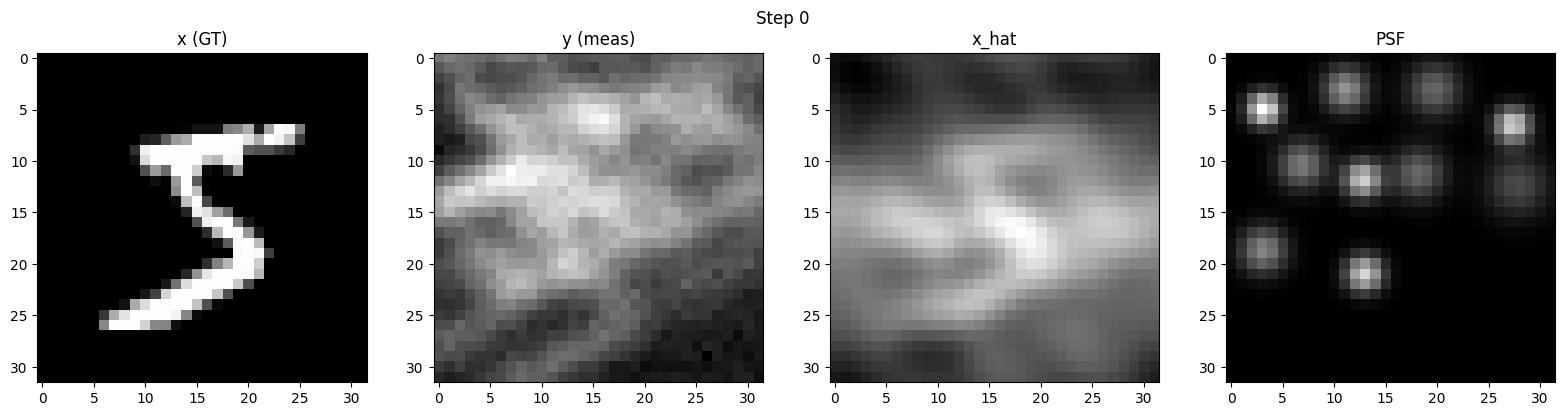

  8%|▊         | 4/50 [00:12<01:27,  1.91s/it]

step 1/50  loss=168727.343750  K=0.367144
step 2/50  loss=171296.156250  K=0.366776
step 3/50  loss=167196.781250  K=0.366409
step 4/50  loss=157323.140625  K=0.366043


 16%|█▌        | 8/50 [00:12<00:26,  1.56it/s]

step 5/50  loss=170239.609375  K=0.365676
step 6/50  loss=177289.968750  K=0.365307
step 7/50  loss=174084.531250  K=0.364939
step 8/50  loss=154298.156250  K=0.364572


 20%|██        | 10/50 [00:12<00:17,  2.33it/s]

step 9/50  loss=162855.546875  K=0.364205
step 10/50  loss=169709.750000  K=0.363836
CORNER VAL: -17.271227


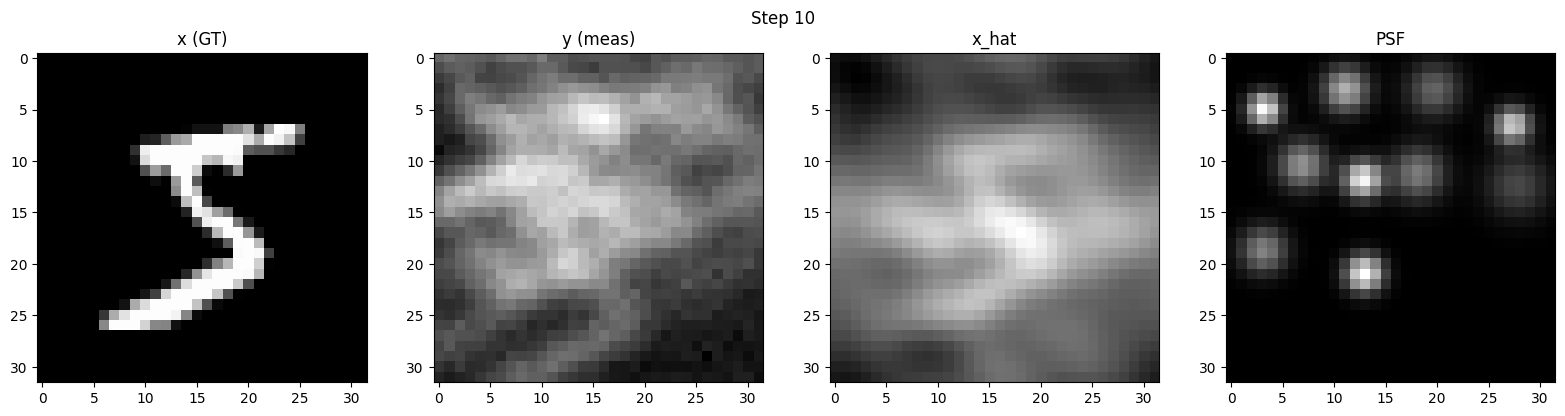

 28%|██▊       | 14/50 [00:13<00:09,  3.82it/s]

step 11/50  loss=159259.750000  K=0.363469
step 12/50  loss=156761.281250  K=0.363102
step 13/50  loss=157490.156250  K=0.362735
step 14/50  loss=161846.859375  K=0.362367


 36%|███▌      | 18/50 [00:13<00:04,  6.47it/s]

step 15/50  loss=153304.031250  K=0.362001
step 16/50  loss=164429.062500  K=0.361633
step 17/50  loss=161825.562500  K=0.361265
step 18/50  loss=146334.843750  K=0.360898


 40%|████      | 20/50 [00:13<00:03,  7.98it/s]

step 19/50  loss=155611.156250  K=0.360531
step 20/50  loss=166005.718750  K=0.360161
CORNER VAL: -17.27125


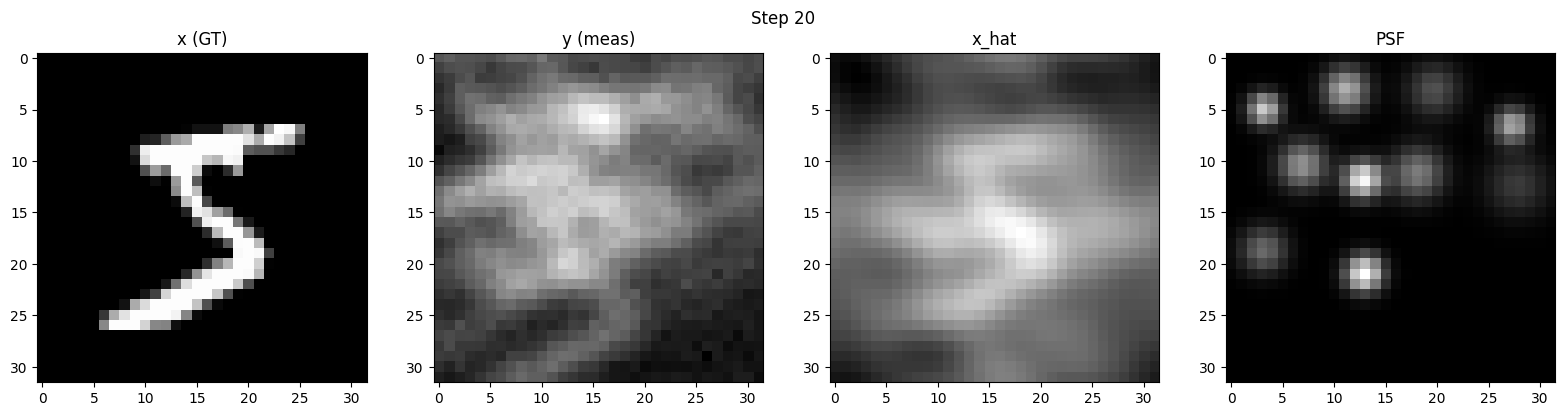

 48%|████▊     | 24/50 [00:14<00:03,  7.75it/s]

step 21/50  loss=161990.875000  K=0.359789
step 22/50  loss=178172.062500  K=0.359412
step 23/50  loss=170489.328125  K=0.359030
step 24/50  loss=163390.703125  K=0.358647


 56%|█████▌    | 28/50 [00:14<00:02, 10.60it/s]

step 25/50  loss=169126.046875  K=0.358262
step 26/50  loss=164701.000000  K=0.357876
step 27/50  loss=170838.093750  K=0.357487
step 28/50  loss=165176.125000  K=0.357097


 60%|██████    | 30/50 [00:14<00:01, 11.85it/s]

step 29/50  loss=156788.937500  K=0.356708
step 30/50  loss=159966.437500  K=0.356319
CORNER VAL: -17.271269


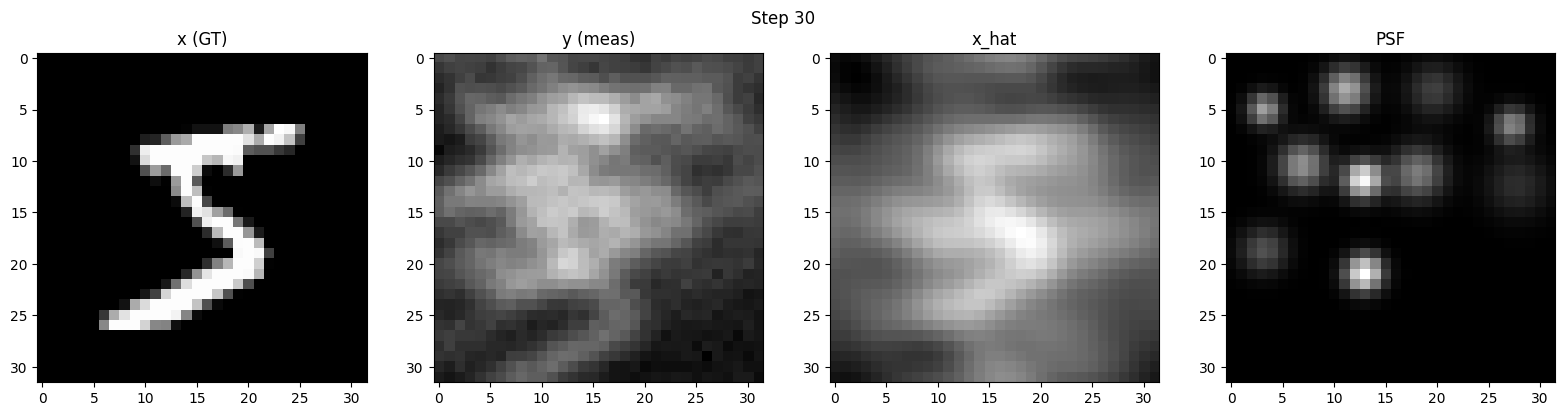

 68%|██████▊   | 34/50 [00:14<00:01,  9.24it/s]

step 31/50  loss=143680.062500  K=0.355934
step 32/50  loss=146005.265625  K=0.355552
step 33/50  loss=130875.203125  K=0.355178
step 34/50  loss=146648.609375  K=0.354803


 76%|███████▌  | 38/50 [00:15<00:01, 11.76it/s]

step 35/50  loss=138133.109375  K=0.354432
step 36/50  loss=136568.343750  K=0.354062
step 37/50  loss=183491.453125  K=0.353677
step 38/50  loss=167977.781250  K=0.353283


 80%|████████  | 40/50 [00:15<00:00, 12.78it/s]

step 39/50  loss=189414.203125  K=0.352875
step 40/50  loss=175363.578125  K=0.352461
CORNER VAL: -17.271284


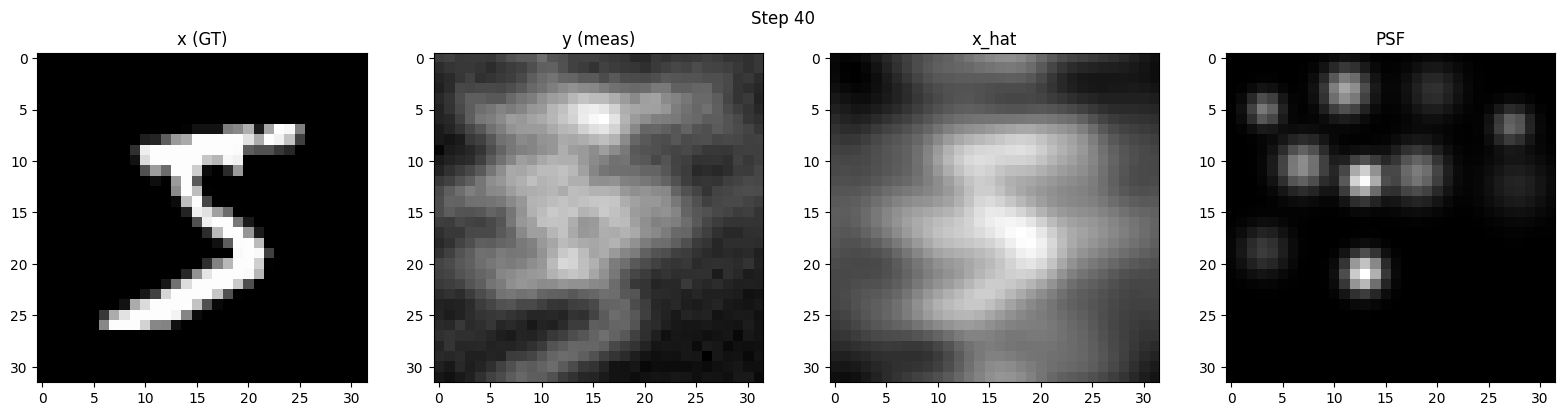

 88%|████████▊ | 44/50 [00:16<00:00,  7.88it/s]

step 41/50  loss=171913.281250  K=0.352043
step 42/50  loss=187879.531250  K=0.351617
step 43/50  loss=182626.750000  K=0.351185
step 44/50  loss=150111.859375  K=0.350760


 96%|█████████▌| 48/50 [00:16<00:00, 10.82it/s]

step 45/50  loss=148436.109375  K=0.350341
step 46/50  loss=144883.828125  K=0.349927
step 47/50  loss=143927.281250  K=0.349520
step 48/50  loss=142480.375000  K=0.349119
step 49/50  loss=145729.406250  K=0.348720
CORNER VAL: -17.2713


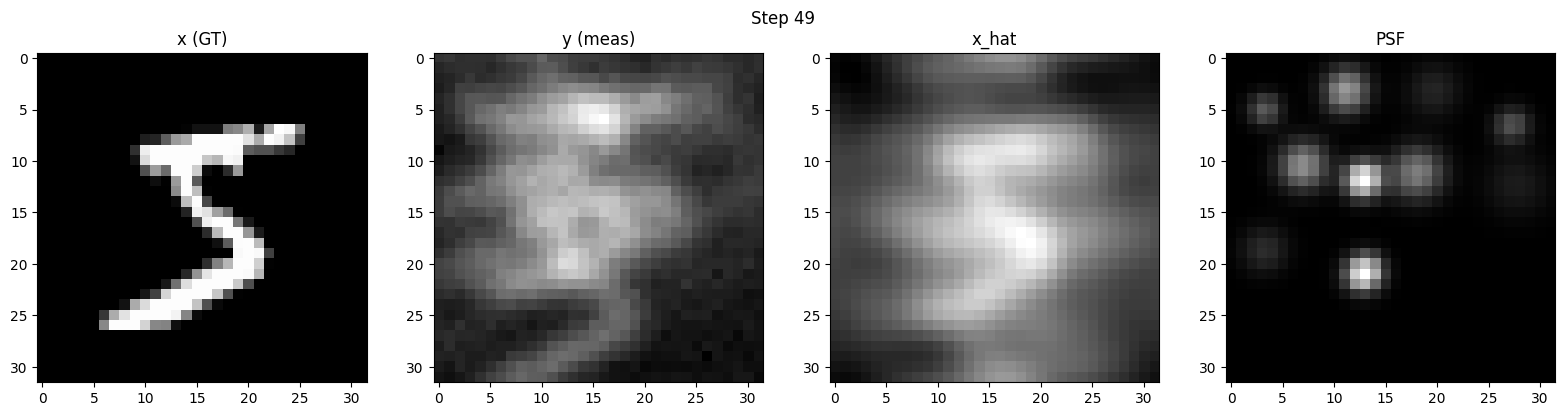

100%|██████████| 50/50 [00:16<00:00,  2.97it/s]


In [13]:
optimized_imaging_system = e2e_optimizer.optimize(
    train_dataset,
    num_steps=50,
    log_every=1,
    visualize_every=10
)

In [14]:
model.log_K

Array(-1., dtype=float32, weak_type=True)